# Bank Marketing Data Analysis and Model Training

# Step 1: Import Required Libraries

In [25]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Step 2: Load the Dataset

In [26]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('/content/bankmarketing.csv')
print(df.head())
print(df.info())

Saving bankmarketing.csv to bankmarketing (2).csv
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   con

## Step 3: Handle Missing Values

In [27]:
df.replace('unknown', np.nan, inplace=True)
df.dropna(inplace=True)

print(f"Data shape after removing missing values: {df.shape}")
print(df.isnull().sum())


Data shape after removing missing values: (30488, 21)
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


## Step 4: Exploratory Data Analysis (EDA)

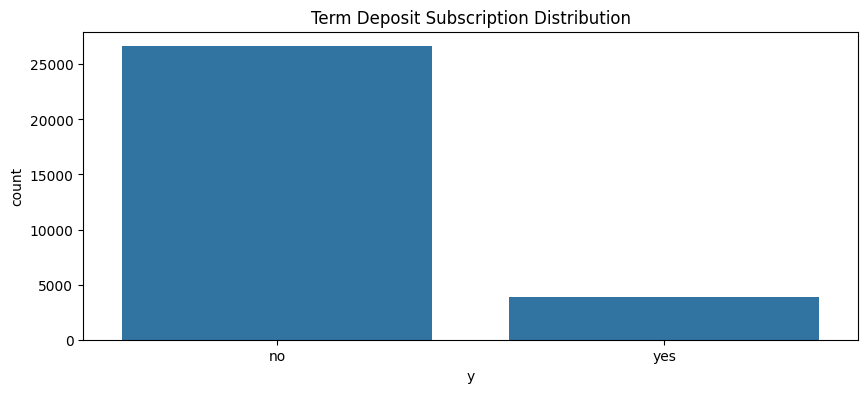

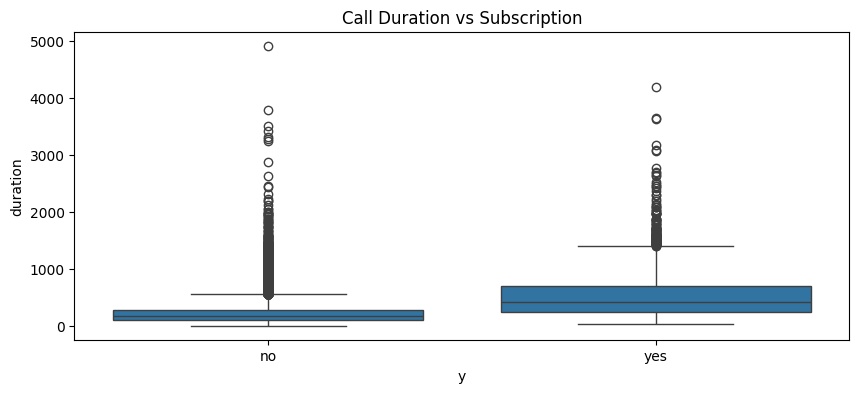

In [28]:
# Plot subscription counts
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='y')
plt.title('Term Deposit Subscription Distribution')
plt.show()

# Boxplot for call duration vs subscription outcome
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='y', y='duration')
plt.title('Call Duration vs Subscription')
plt.show()


## Step 5: Encode Categorical Columns

In [29]:

cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
print(df.head())


   age  job  marital  education  default  housing  loan  contact  month  \
0   56    3        1          0        0        0     0        1      6   
2   37    7        1          3        0        1     0        1      6   
3   40    0        1          1        0        0     0        1      6   
4   56    7        1          3        0        0     1        1      6   
6   59    0        1          5        0        0     0        1      6   

   day_of_week  ...  campaign  pdays  previous  poutcome  emp.var.rate  \
0            1  ...         1    999         0         1           1.1   
2            1  ...         1    999         0         1           1.1   
3            1  ...         1    999         0         1           1.1   
4            1  ...         1    999         0         1           1.1   
6            1  ...         1    999         0         1           1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed  y  
0          93.994          -36.4      4.85

## Step 6: Normalize Numerical Features

In [30]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = numerical_cols.drop('y', errors='ignore')
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
print(df.describe())


                age           job       marital     education       default  \
count  3.048800e+04  3.048800e+04  3.048800e+04  3.048800e+04  3.048800e+04   
mean  -1.939030e-16  3.169569e-17  9.695151e-17  2.237343e-17  1.631396e-18   
std    1.000016e+00  1.000016e+00  1.000016e+00  1.000016e+00  1.000016e+00   
min   -2.131931e+00 -1.028791e+00 -1.913228e+00 -1.932139e+00 -9.920134e-03   
25%   -7.770959e-01 -1.028791e+00 -3.097727e-01 -9.265476e-01 -9.920134e-03   
50%   -1.964523e-01 -4.751876e-01 -3.097727e-01 -4.237517e-01 -9.920134e-03   
75%    5.777393e-01  9.088205e-01  1.293682e+00  1.084636e+00 -9.920134e-03   
max    5.416437e+00  1.739225e+00  1.293682e+00  1.084636e+00  1.008051e+02   

            housing          loan       contact         month   day_of_week  \
count  3.048800e+04  3.048800e+04  3.048800e+04  3.048800e+04  3.048800e+04   
mean  -8.576480e-17 -3.169569e-17  2.983124e-17  5.966247e-17 -5.966247e-17   
std    1.000016e+00  1.000016e+00  1.000016e+00  1.

## Step 7: Split the Dataset

In [31]:
X = df.drop('y', axis=1)
y = df['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)



Train shape: (24390, 20)
Test shape: (6098, 20)


## Step 8: Train and Evaluate Models

In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))



Logistic Regression Results:
Accuracy: 0.8955395211544769
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94      5304
           1       0.66      0.40      0.50       794

    accuracy                           0.90      6098
   macro avg       0.79      0.69      0.72      6098
weighted avg       0.88      0.90      0.88      6098

Confusion Matrix:
 [[5142  162]
 [ 475  319]]

Decision Tree Results:
Accuracy: 0.8758609380124631
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      5304
           1       0.52      0.52      0.52       794

    accuracy                           0.88      6098
   macro avg       0.73      0.72      0.72      6098
weighted avg       0.88      0.88      0.88      6098

Confusion Matrix:
 [[4931  373]
 [ 384  410]]

Random Forest Results:
Accuracy: 0.9014430960970811
Classification Report:
               pre

## Step 9: Feature Importance Visualization

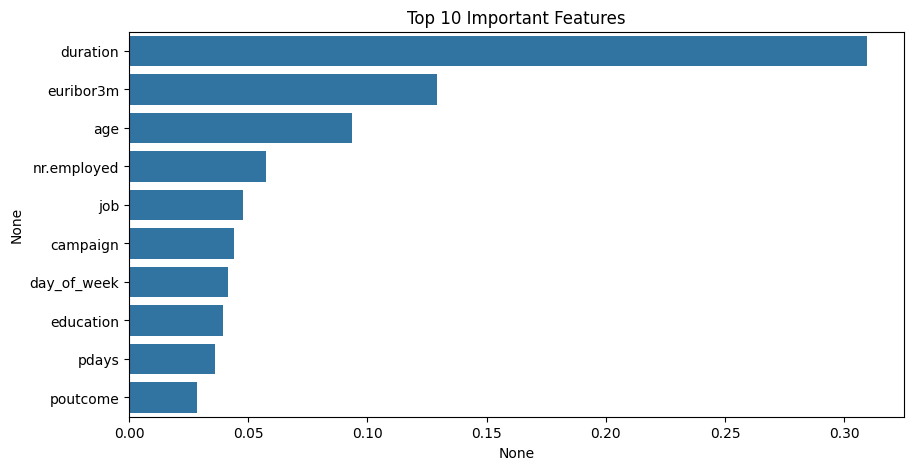

In [33]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=feat_imp[:10], y=feat_imp.index[:10])
plt.title("Top 10 Important Features")
plt.show()